# 3. Improving Reasoning with Inference-Time Scaling

---

Packages used in this notebook:

In [1]:
from importlib.metadata import version

used_libraries = [
    "matplotlib",
    "reasoning_llm_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_llm_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

matplotlib version: 3.11.1
reasoning_llm_from_scratch version: 0.1.0
torch version: 2.14.0
tokenizers version: 0.23.2


## 3.1. Loading the pre-trained model

In [2]:
from reasoning_llm_from_scratch.generate_text_pretrained_llm import get_device
from reasoning_llm_from_scratch.evaluate_reasoning_llm import load_model_and_tokenizer

device = get_device()

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=True
)

Using Apple Silicon GPU (MPS)
✓ ../qwen3/qwen3-0.6B-base.pth already up-to-date


Let's try the model on a prompt from the MATH-500 dataset like the previous notebook.

In [3]:
from reasoning_llm_from_scratch.evaluate_reasoning_llm import render_prompt

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


The following function is based on generate_text_stream_concat from the previous chapter, but we modify it slightly to be able to pass in other `generate_*` functions later.

In [4]:
from reasoning_llm_from_scratch.generate_text_pretrained_llm import generate_text_basic_stream_cache
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import generate_text_stream_concat_flex

In [5]:
response = generate_text_stream_concat_flex(
    model, 
    tokenizer, 
    prompt, 
    device,
    max_new_tokens=2048, 
    verbose=True,
    generate_func=generate_text_basic_stream_cache  # NEW
)

 \boxed{10}

This correct answer is supposed to be 83.

## 4.2. Generating better responses with chain-of-thought prompting

A classic way to improve model performance is to modify the prompt to encourage the model to think or explain step by step.

In [6]:
prompt_cot = prompt + " \n\nExplain step by step."

response_cot = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
)

 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
According to the problem, half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

## 4.3. Controlling output diversity with temperature scaling

So far, we have used deterministic decoding, and from now one we will work with stochastic decoding.

We can begin by giving ourselves a recap and **understanding the process of selecting the next token**.

In [7]:
ex_prompt = "The capital of Germany is"

response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=1, verbose=True
)

 Berlin

The exact step by step process under the hood of something as simple as the above code block is as follows.

In [8]:
# 1) Convert input text into token IDs
import torch

input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)

print(input_token_ids)

tensor([[ 785, 6722,  315, 9856,  374]], device='mps:0')


In [9]:
# 2) Get scores for next token

with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)  # Shape: [1, vocab_size]

torch.Size([1, 151936])


In [10]:
# 3) Find vocabulary index with highest score

max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID: 19846
Decoded token: ' Berlin'


The LLM has a vocabulary size of 151,936 tokens with token indices 0 to 151,935; we only focus on a subset of 100 tokens between indices 19,800 and 19,900 (easier to visualize).

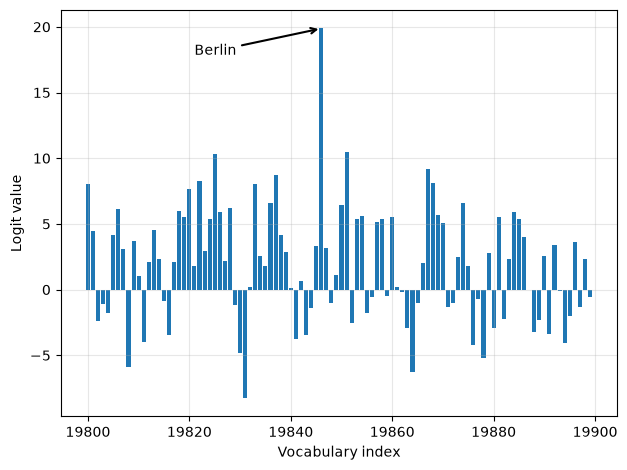

In [11]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import plot_scores_bar

plot_scores_bar(next_token_logits)

Now that it's clear how the model selects its next token, we can introduce the concept of temperature which is a parameter that rescales the logits and makes the corresponding probability distribution sharper or flatter and thereby affects how the next token is selected. **Rescaling token scores (logits) via a temperature parameter**.

In [12]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import scale_logits_by_temperature

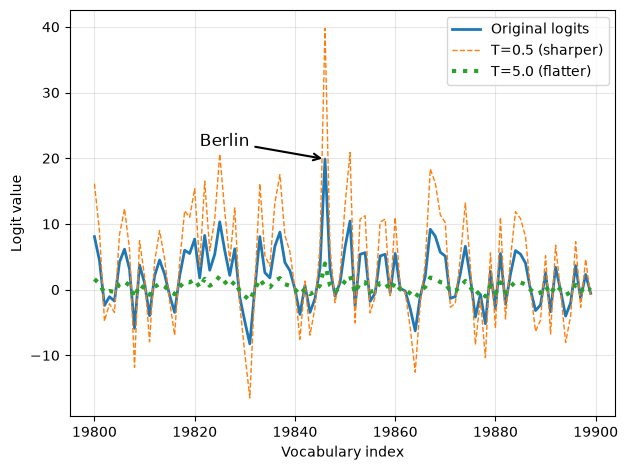

In [13]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import plot_logits_with_temperature

plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

**Sampling the next token from a probability distribution** will require converting logits scores to probability scores, which sum up to 1.

In [14]:
# Step 3.2: Rescale next-token scores
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

# Step 3.3 Convert rescaled logits into probability scores
next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)

print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., device='mps:0', dtype=torch.bfloat16)


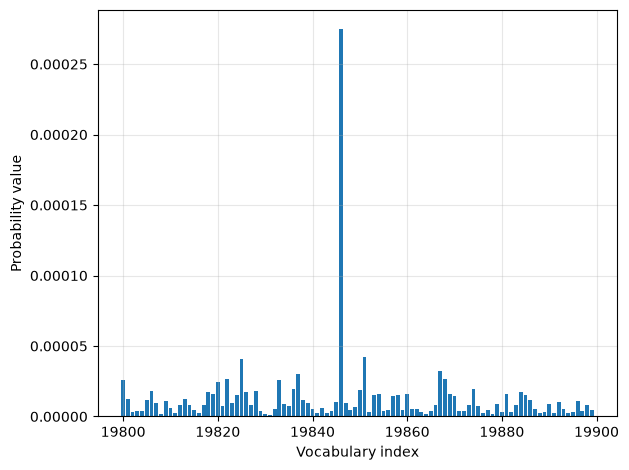

In [15]:
plot_scores_bar(
    next_token_probas, arrow=False, ylabel="Probability value"
)

In [16]:
print("Token ID 19,846 probability:", next_token_probas[:, 19846])

Token ID 19,846 probability: tensor([0.0003], device='mps:0', dtype=torch.bfloat16)


In [17]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.0003, device='mps:0', dtype=torch.bfloat16)


In [18]:
# Step 3.4: Sample token according to probabilities
torch.manual_seed(123)
print(
    "Sampled token:",
    torch.multinomial(next_token_probas.cpu(), num_samples=1)
)

Sampled token: tensor([[65094]])


In [19]:
print(tokenizer.decode([65094]))

 mistress


In [20]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import count_samples

In [21]:
torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)

' your': 2x
' Schw': 2x
' Lan': 2x
' peril': 2x
'�': 2x
' אותו': 2x


In [22]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

'
': 2x
' (': 2x
' __': 156x
' ___': 2x
' Berlin': 432x
' ____': 169x
' ______': 205x
' Munich': 6x
' Hamburg': 6x
' _____': 18x


In [23]:
print(probas_lowT[0, 19_846])

tensor(0.4180, device='mps:0', dtype=torch.bfloat16)


Now we can **add temperature scaling to the text generation function**.

In [24]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import generate_text_temp_stream_cache

In [25]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

 \boxed{$x = \frac{9 + 7q + 3 \sqrt{69 + 24\sqrt{69 + 24\sqrt{69 + 24\sqrt{69 + 24\sqrt{69 + 24\sqrt{69 + 24\sqrt{69}}}}}} + 36\sqrt{3} + 7\sqrt{3(69 + 24\sqrt{69}}}{16}$}

The correct answer is 83, so the model is still wrong, but this was meant as a demonstration to show that we can tweak the answer by using temperature scaling and sampling.

## 3.4. Balancing diversity and coherence with top-p sampling

We’ll now improve the sampling process by adding a top-p filter so that very low-confidence tokens are not sampled by accident. The top-p sampling process implemented here is also known as nucleus sampling. 

Before we implement the top-p filter, let’s introduce a simple toy dataset that will make the temperature-scaling and sampling process easier to illustrate.

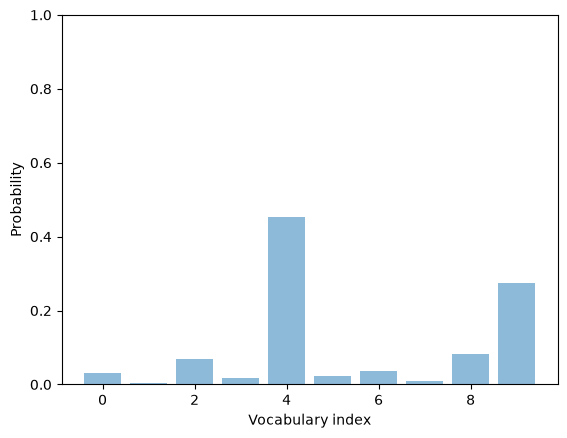

In [26]:
import matplotlib.pyplot as plt

# Step 3.1: Get logits (here: use toy logits for 10 tokens)
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

# Step 3.2: Apply temperature scaling
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)

# Step 3.3: Convert to probabilities
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)

plt.bar(
    torch.arange(len(toy_logits_scaled)), toy_probas,
    alpha=0.5
)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
plt.show()

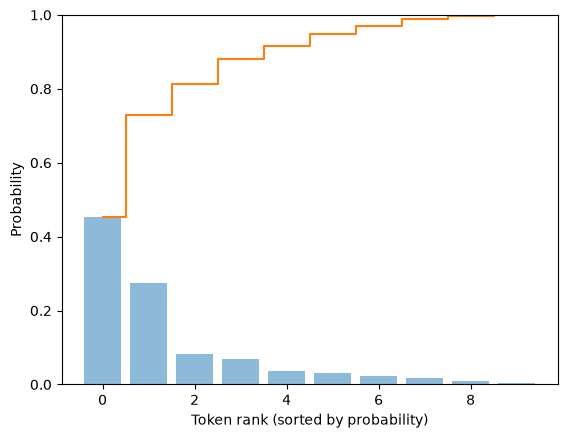

In [27]:
# Step 4.1: Sort by descending probability
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)

# Step 4.2: Compute cumulative sum
cumsum = torch.cumsum(sorted_probas, dim=-1)

plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
        alpha=0.5
)
plt.step(
    torch.arange(len(cumsum)), cumsum, 
    where="mid", color="C1", label="Cumulative sum"
)

plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

Now that we have the cumulative probability sum, we can implement the core top-p filtering step. Top-p can be translated as “keep the smallest set of tokens whose cumulative probability stays below or equal to p.”

In [28]:
# Step 4.3.1: Apply top-p threshold (e.g., keep tokens until cumulative mass > 0.8)
top_p = 0.8
keep_mask = cumsum <= top_p
n_kept = torch.sum(keep_mask).item()
print("Cumulative sum:", cumsum)
print("Tokens kept:", n_kept)

Cumulative sum: tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])
Tokens kept: 2


In [29]:
# A more common variant is to include the token that crosses the threshold
keep_mask = (cumsum - sorted_probas) < top_p
n_kept = keep_mask.sum().item()
print("Tokens kept:", n_kept)

Tokens kept: 3


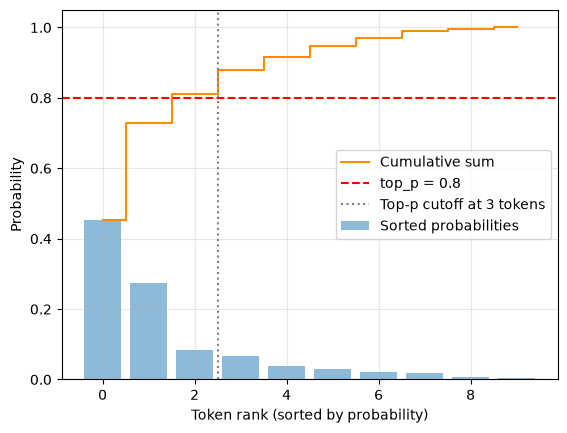

In [30]:
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
    alpha=0.5, label="Sorted probabilities"
)
plt.step(
    torch.arange(len(cumsum)), cumsum, where="mid",
    color="darkorange", label="Cumulative sum"
)

# Highlight cutoff
plt.axhline(
    top_p, color="red", linestyle="--",
    label=f"top_p = {top_p}"
)
plt.axvline(
    n_kept - 0.5, color="gray", linestyle=":",
    label=f"Top-p cutoff at {n_kept} tokens"
)

plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

In [31]:
# Step 4.3.2: Zero out beyond cutoff
kept_sorted = torch.where(
    keep_mask, sorted_probas,
    torch.zeros_like(sorted_probas)
)

# Step 4.3.3: Map back to original order
filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)

print(filtered)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0829,
        0.2752])


In [32]:
# Step 4.4: Renormalize to sum to 1
denom = torch.sum(filtered).clamp_min(1e-12)
renormalized = filtered / denom
print(renormalized)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5589, 0.0000, 0.0000, 0.0000, 0.1021,
        0.3390])


We can finally **add a top-p filter to the text generation function**.

In [33]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import top_p_filter

In [34]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [35]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

'
': 2x
' (': 2x
' __': 156x
' ___': 2x
' Berlin': 432x
' ____': 169x
' ______': 205x
' Munich': 6x
' Hamburg': 6x
' _____': 18x


In [36]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)

count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' Berlin': 534x
' ____': 217x
' ______': 249x


In [37]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import generate_text_top_p_stream_cache

In [38]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8, 
)

 \boxed{18}

The answer is still incorrect. Everything we have done so far is to let us sample different outputs. In the next section, we’ll use `generate_text_stream_concat_flex` with our augmented text generation function (`generate_text_top_p_stream_cache`) to sample different outputs when implementing the self-consistency inference-time-scaling technique.

## 3.5. Improving response accuracy with self-consistency

This method works by sampling multiple reasoning chains with high temperature and top-p, extracting the final answer from each chain and then choosing the most frequent final answer.

In [39]:
from reasoning_llm_from_scratch.improve_reasoning_inference_time_scaling import self_consistency_vote

In [40]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → '83'
[Sample 2/5] → '22'
[Sample 3/5] → '54'
[Sample 4/5] → '83'
[Sample 5/5] → '66'


In [41]:
print(results["final_answer"])

83


In [42]:
print(results["full_answers"][0])

 To find the value of \( x \), let's solve the equation step by step.

1. **Given Equation:**
   \[
   \text{Half the value of } 3x - 9 \text{ is } x + 37.
   \]
   This can be written as:
   \[
   \frac{1}{2}(3x - 9) = x + 37.
   \]

2. **Multiply Both Sides by 2 to Eliminate the Fraction:**
   \[
   2 \times \frac{1}{2}(3x - 9) = 2 \times (x + 37).
   \]
   Simplifying both sides:
   \[
   3x - 9 = 2x + 74.
   \]

3. **Subtract \( 2x \) from Both Sides to Get the \( x \)-terms on One Side:**
   \[
   3x - 2x - 9 = 74.
   \]
   Simplifying:
   \[
   x - 9 = 74.
   \]

4. **Add 9 to Both Sides to Solve for \( x \):**
   \[
   x - 9 + 9 = 74 + 9.
   \]
   Simplifying:
   \[
   x = 83.
   \]

**Final Answer:**
\[
\boxed{83}
\]


With this self-consistency approach, we were finally able to generate the correct answer.

Note: **The `self_consistency_vote` function does not currently handle ties, so if multiple samples have the same frequency, it returns None as the final answer**.

Let’s now combine chain-of-thought prompting with self-consistency sampling.

In [43]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → '83'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '83'
[Sample 5/5] → '83'


In this case, all five answers are 83 (correct), likely because the question is relatively simple for the LLM when using chains of thought.